 # Explore Latent Video Dataset

 Load encoded DC-AE latent episodes, inspect shapes/stats, decode back to frames.

In [1]:
import sys, os, io, json
#os.chdir(os.path.dirname(os.path.dirname(os.path.abspath(__file__))))
sys.path.insert(0, ".")

import numpy as np
import torch
import webdataset as wds
import matplotlib.pyplot as plt
from pathlib import Path

LATENT_DIR = "../datasets/pvp_latents"


 ## 1. Index shards and stream episodes

In [2]:
shards = sorted(Path(LATENT_DIR).glob("latent-*.tar"))
shard_urls = [str(s) for s in shards]
print(f"Found {len(shards)} shards, {sum(s.stat().st_size for s in shards) / 1e9:.1f} GB total")


Found 31 shards, 112.5 GB total


 ## 2. Build a WebDataset pipeline

In [3]:
def make_dataset(shard_urls, shuffle=False, clip_len=0, player="p1"):
    """Build a WebDataset that yields parsed episode dicts.

    If clip_len > 0, only loads the arrays for `player` and slices a random
    clip *during* npy deserialization to avoid loading the full ~190MB array.
    """
    ds = wds.WebDataset(shard_urls, shardshuffle=shuffle, handler=wds.warn_and_continue)
    if shuffle:
        ds = ds.shuffle(100)

    def decode_sample(sample):
        out = {"__key__": sample["__key__"]}
        for k, v in sample.items():
            if k == "meta.json":
                out["meta"] = json.loads(v)
            elif k.endswith(".npy"):
                name = k.replace(".npy", "")
                # When clip sampling, skip arrays we don't need
                if clip_len > 0 and player not in name:
                    continue
                out[name] = np.load(io.BytesIO(v))
        return out

    ds = ds.map(decode_sample)

    if clip_len > 0:
        def _clip(sample):
            lat = sample[f"latents_{player}"]
            n = lat.shape[0]
            start = np.random.randint(0, max(1, n - clip_len))
            end = start + clip_len
            return {
                "latents": lat[start:end],
                "actions": sample[f"actions_{player}"][start:end],
                "rewards": sample[f"rewards_{player}"][start:end],
            }
        ds = ds.map(_clip)

    return ds


ds = make_dataset(shard_urls)

# Load first episode to inspect
sample = next(iter(ds))
print(f"Episode: {sample['__key__']}")
print(f"Scenario: {sample['meta'].get('scenario', '?')}")
print(f"PvP: {sample['meta'].get('is_pvp', False)}")
print()
for k, v in sample.items():
    if isinstance(v, np.ndarray):
        print(f"  {k:20s}  shape={str(v.shape):20s}  dtype={v.dtype}  range=[{v.min():.3f}, {v.max():.3f}]")


Episode: ep_330eac3f-d3d8-4cda-a89d-4bd57371d2bb
Scenario: dwango5_5min
PvP: True

  actions_p1            shape=(10442, 14)           dtype=float32  range=[-12.500, 12.500]
  actions_p2            shape=(10442, 14)           dtype=float32  range=[-12.500, 12.500]
  latents_p1            shape=(10442, 32, 15, 20)   dtype=float16  range=[-18.953, 18.641]
  latents_p2            shape=(10442, 32, 15, 20)   dtype=float16  range=[-17.297, 18.812]
  rewards_p1            shape=(10442,)              dtype=float32  range=[0.000, 0.000]
  rewards_p2            shape=(10442,)              dtype=float32  range=[0.000, 0.000]


 ## 3. Load a batch of latent clips (for training)

In [4]:
def clip_sampler(sample, clip_len=16, player="p1"):
    """Extract a random clip from an episode."""
    lat = sample[f"latents_{player}"]   # (N, 32, 15, 20)
    act = sample[f"actions_{player}"]   # (N, 14)
    rew = sample[f"rewards_{player}"]   # (N,)
    n = lat.shape[0]
    start = np.random.randint(0, max(1, n - clip_len))
    end = start + clip_len
    return {
        "latents": lat[start:end],
        "actions": act[start:end],
        "rewards": rew[start:end],
        "meta": sample["meta"],
    }


def numpy_collate(batch):
    return {
        "latents": torch.from_numpy(np.stack([s["latents"] for s in batch])),
        "actions": torch.from_numpy(np.stack([s["actions"] for s in batch])),
        "rewards": torch.from_numpy(np.stack([s["rewards"] for s in batch])),
    }


CLIP_LEN = 16
BATCH_SIZE = 8

train_ds = (
    make_dataset(shard_urls, shuffle=True)
    .map(lambda s: clip_sampler(s, clip_len=CLIP_LEN))
)
train_loader = torch.utils.data.DataLoader(
    train_ds, batch_size=BATCH_SIZE, collate_fn=numpy_collate, num_workers=0,
)

batch = next(iter(train_loader))
for k, v in batch.items():
    print(f"  {k:10s}  {str(v.shape):25s}  {v.dtype}")


/share/NFS/u/wendler/code/doom-arena/.venv/lib/python3.12/site-packages/webdataset/compat.py:381: UserWarning: set WebDataset(shardshuffle=...) to a positive integer or 0 or False
  warnings.warn("set WebDataset(shardshuffle=...) to a positive integer or 0 or False")


  latents     torch.Size([8, 16, 32, 15, 20])  torch.float16
  actions     torch.Size([8, 16, 14])    torch.float32
  rewards     torch.Size([8, 16])        torch.float32


 ## 4. Latent statistics

Latent stats (batch of clips):
  mean=0.4310  std=1.9686
  min=-11.4922  max=18.4375


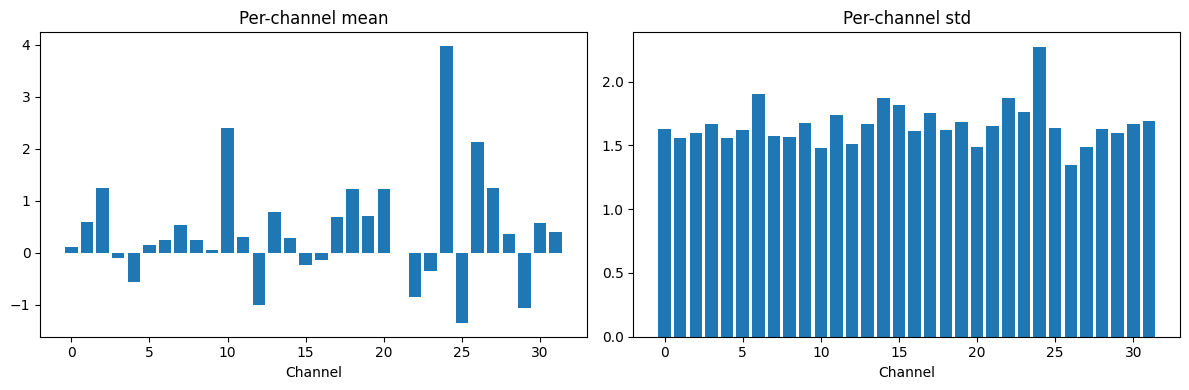

In [5]:
lat = batch["latents"].float()
print(f"Latent stats (batch of clips):")
print(f"  mean={lat.mean():.4f}  std={lat.std():.4f}")
print(f"  min={lat.min():.4f}  max={lat.max():.4f}")

# Per-channel stats
channel_mean = lat.mean(dim=(0, 1, 3, 4))  # (32,)
channel_std = lat.std(dim=(0, 1, 3, 4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(32), channel_mean.numpy())
axes[0].set_title("Per-channel mean")
axes[0].set_xlabel("Channel")
axes[1].bar(range(32), channel_std.numpy())
axes[1].set_title("Per-channel std")
axes[1].set_xlabel("Channel")
plt.tight_layout()
plt.show()


 ## 5. Action distribution

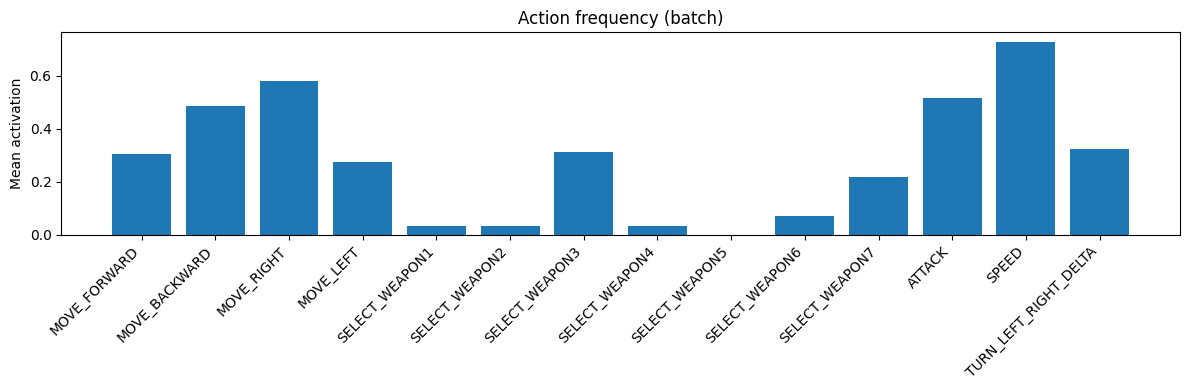

In [6]:
act = batch["actions"]  # (B, T, 14)

# Try to get button names from a sample
sample0 = next(iter(make_dataset(shard_urls)))
button_names = sample0["meta"].get("button_names", [f"btn_{i}" for i in range(14)])

act_flat = act.reshape(-1, 14).numpy()
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(14), act_flat.mean(axis=0))
ax.set_xticks(range(14))
ax.set_xticklabels(button_names, rotation=45, ha="right")
ax.set_title("Action frequency (batch)")
ax.set_ylabel("Mean activation")
plt.tight_layout()
plt.show()


 ## 6. Load DC-AE and decode latents back to frames

In [7]:
from diffusers import AutoencoderDC

MODEL_ID = "mit-han-lab/dc-ae-lite-f32c32-sana-1.1-diffusers"
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Loading DC-AE on {device}...")
dc_ae = AutoencoderDC.from_pretrained(MODEL_ID, torch_dtype=torch.float16).to(device).eval()
print(f"  VRAM: {torch.cuda.memory_allocated(device)/1e9:.2f} GB" if device == "cuda" else "  (CPU)")


/share/NFS/u/wendler/code/doom-arena/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading DC-AE on cuda...
  VRAM: 0.84 GB


In [8]:
def decode_latents(dc_ae, latents, device="cuda", batch_size=16):
    """Decode latent array back to uint8 RGB frames.

    Args:
        latents: (N, 32, 15, 20) float16 numpy array or torch tensor
    Returns:
        (N, H, W, 3) uint8 numpy array
    """
    if isinstance(latents, np.ndarray):
        latents = torch.from_numpy(latents)
    latents = latents.to(device).half()

    frames = []
    for start in range(0, len(latents), batch_size):
        b = latents[start:start + batch_size]
        with torch.no_grad():
            decoded = dc_ae.decode(b).sample  # (B, 3, H, W)
        rgb = decoded.mul(0.5).add(0.5).clamp_(0, 1).mul_(255).byte()
        frames.append(rgb.permute(0, 2, 3, 1).cpu().numpy())  # (B, H, W, 3)
    return np.concatenate(frames, axis=0)


# Decode the first clip from our batch
sample_latents = batch["latents"][0].numpy()  # (T, 32, 15, 20)
decoded_frames = decode_latents(dc_ae, sample_latents)
print(f"Decoded: {decoded_frames.shape} {decoded_frames.dtype}")


Decoded: (16, 480, 640, 3) uint8


 ## 7. Visualize decoded frames

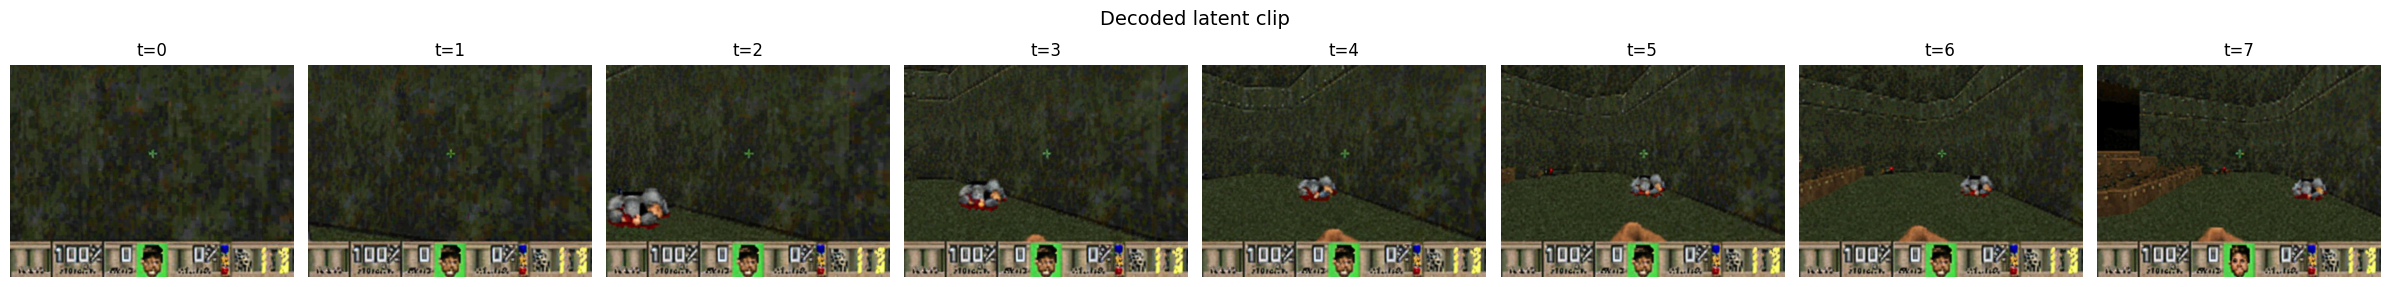

In [9]:
n_show = min(8, decoded_frames.shape[0])
fig, axes = plt.subplots(1, n_show, figsize=(3 * n_show, 3))
for i in range(n_show):
    axes[i].imshow(decoded_frames[i])
    axes[i].set_title(f"t={i}")
    axes[i].axis("off")
fig.suptitle("Decoded latent clip", fontsize=14)
plt.tight_layout()
plt.show()


 ## 8. Side-by-side P1 vs P2 (PvP episode)

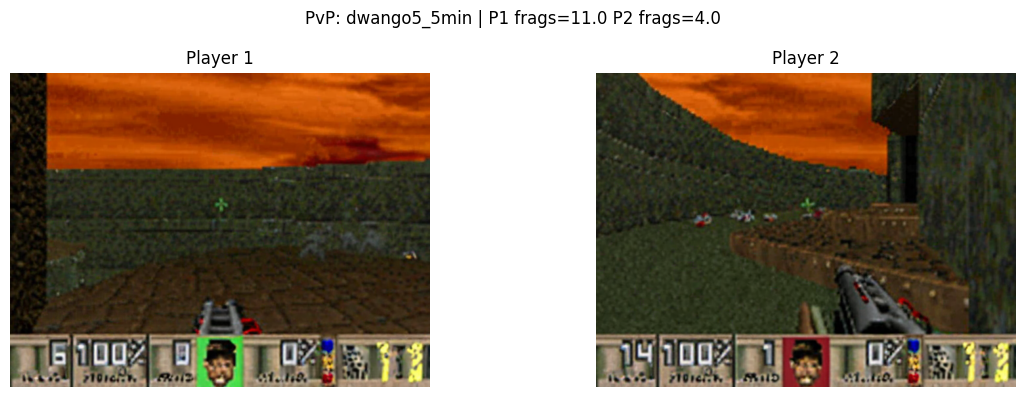

In [10]:
# Find a PvP episode
pvp_ds = make_dataset(shard_urls).select(lambda s: s["meta"].get("is_pvp", False))
try:
    pvp_sample = next(iter(pvp_ds))
    t = pvp_sample["latents_p1"].shape[0] // 2  # mid-game frame

    frames_p1 = decode_latents(dc_ae, pvp_sample["latents_p1"][t:t+1])
    frames_p2 = decode_latents(dc_ae, pvp_sample["latents_p2"][t:t+1])

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].imshow(frames_p1[0])
    axes[0].set_title("Player 1")
    axes[0].axis("off")
    axes[1].imshow(frames_p2[0])
    axes[1].set_title("Player 2")
    axes[1].axis("off")
    meta = pvp_sample["meta"]
    fig.suptitle(f"PvP: {meta.get('scenario','?')} | "
                 f"P1 frags={meta.get('frag_p1','?')} P2 frags={meta.get('frag_p2','?')}")
    plt.tight_layout()
    plt.show()
except StopIteration:
    print("No PvP episodes found in current shards")


## 9. Using the LatentTrainLoader (production dataloader)

The `LatentTrainLoader` is the streaming loader used for actual training. It explodes
each episode into all non-overlapping clips, shuffles at the shard level, and keeps
P1/P2 temporally aligned. On local NVMe it achieves ~20,000 frames/s.

In [ ]:
import time
from doom_arena.latent_loader import LatentDataset, LatentTrainLoader

# --- Random-access dataset ---
ds = LatentDataset(LATENT_DIR)
ds.summary()

ep = ds[0]
print(f"\n{ep}")
print(f"  latents_p1: {ep.latents_p1.shape} {ep.latents_p1.dtype}")
print(f"  latents_p2: {ep.latents_p2.shape} {ep.latents_p2.dtype}")
print(f"  actions_p1: {ep.actions_p1.shape}")

# Frame-level indexing
clip = ep[100:116]
print(f"\n  ep[100:116] -> latents_p1: {clip['latents_p1'].shape}")

# --- Streaming training loader ---
CLIP_LEN = 16
BATCH_SIZE = 32

loader = LatentTrainLoader(
    LATENT_DIR,
    clip_len=CLIP_LEN,
    batch_size=BATCH_SIZE,
    num_workers=4,
    num_samples=1000,
)
print(f"\nLatentTrainLoader: {loader.num_batches} batches, {loader.num_samples} samples")

t0 = time.time()
for i, batch in enumerate(loader):
    if i == 0:
        print(f"\nBatch shapes:")
        for k, v in batch.items():
            print(f"  {k:15s} {str(v.shape):30s} {v.dtype}")
    if i >= 10:
        break

elapsed = time.time() - t0
total_frames = (i + 1) * BATCH_SIZE * CLIP_LEN
print(f"\n{i+1} batches in {elapsed:.1f}s = {total_frames/elapsed:.0f} frames/s")